# 1. Exploratory Data Analysis — Respiratory Sound Database

This notebook explores the ICBHI 2017 Respiratory Sound Database:
- Dataset structure and file parsing
- Patient demographics and diagnosis distribution
- Respiratory cycle class distribution (normal / crackle / wheeze / both)
- Audio waveform and spectrogram visualisation
- Recording characteristics (duration, sampling rate, chest location)

In [ ]:
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
from pathlib import Path

from src.config import * # type: ignore
from src.data_loader import ( # type: ignore
    build_cycle_dataset,
    load_diagnosis,
    load_demographics,
    load_cycle_audio,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')

Setup complete.


## 1.1 Load Metadata

In [3]:
# Load patient diagnosis and demographics
diagnosis_df = load_diagnosis()
demographics_df = load_demographics()

print(f'Patients with diagnosis: {len(diagnosis_df)}')
print(f'Patients with demographics: {len(demographics_df)}')

diagnosis_df.head()

Patients with diagnosis: 126
Patients with demographics: 126


,patient_id,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


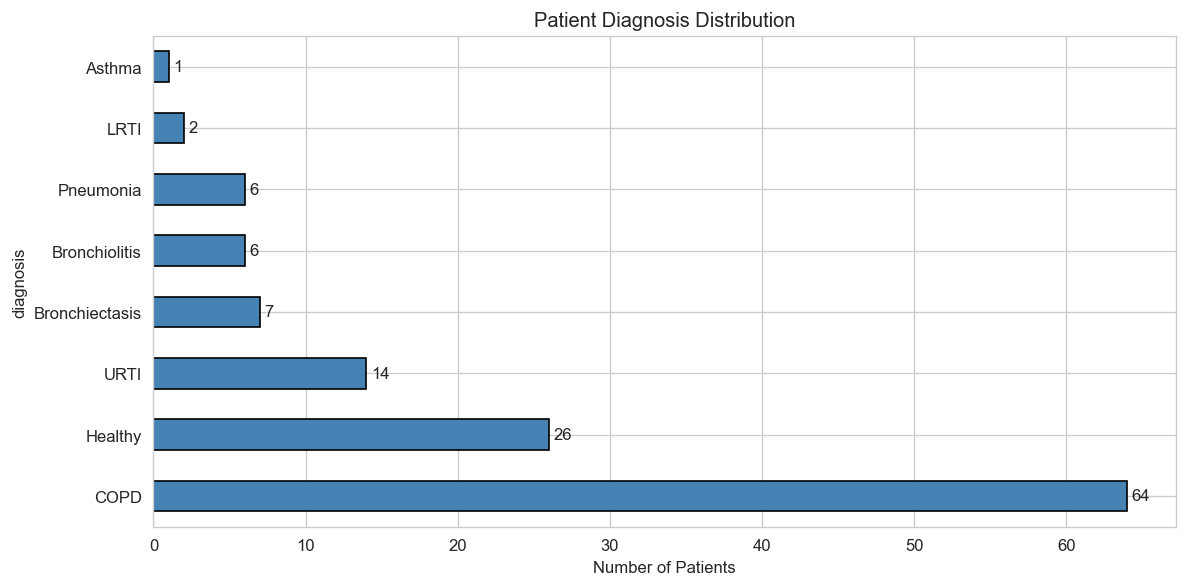

In [4]:
# Diagnosis distribution
fig, ax = plt.subplots(figsize=(10, 5))
diagnosis_counts = diagnosis_df['diagnosis'].value_counts()
diagnosis_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Patients')
ax.set_title('Patient Diagnosis Distribution')
for i, (v, name) in enumerate(zip(diagnosis_counts.values, diagnosis_counts.index)):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'diagnosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Demographics overview
demographics_df.describe()

,patient_id,age,adult_bmi,child_weight,child_height
count,126.000000,125.00000,75.000000,44.000000,42.000000
mean,163.500000,42.99264,27.190000,21.361136,104.652381
std,36.517119,32.20907,5.372519,17.150885,30.793128
min,101.000000,0.25000,16.500000,7.140000,64.000000
25%,132.250000,4.00000,24.150000,11.755000,81.250000
50%,163.500000,60.00000,27.400000,15.100000,99.500000
75%,194.750000,71.00000,29.185000,24.325000,117.750000
max,226.000000,93.00000,53.500000,80.000000,183.000000


## 1.2 Build Cycle-Level Dataset

In [6]:
# Parse all annotations → one row per respiratory cycle
cycle_df = build_cycle_dataset()
cycle_df.head(10)

Found 920 annotation files.
Total respiratory cycles: 6898


,audio_path,annotation_path,patient_id,recording_index,chest_location,acquisition_mode,recording_equipment,start,end,duration,crackle,wheeze,label
0,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,0.036,0.579,0.543,0.0,0.0,0.0
1,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,0.579,2.450,1.871,0.0,0.0,0.0
2,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,2.450,3.893,1.443,0.0,0.0,0.0
3,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,3.893,5.793,1.900,0.0,0.0,0.0
4,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,5.793,7.521,1.728,0.0,0.0,0.0
5,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,7.521,9.279,1.758,0.0,0.0,0.0
6,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,9.279,11.150,1.871,0.0,0.0,0.0
7,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,11.150,13.036,1.886,0.0,0.0,0.0
8,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,13.036,14.721,1.685,0.0,0.0,0.0
9,E:\Cardiff Uni\Projects\Sound-based lung disea...,E:\Cardiff Uni\Projects\Sound-based lung disea...,101,1b1,Al,sc,Meditron,14.721,16.707,1.986,0.0,0.0,0.0


In [7]:
# Merge with diagnosis
cycle_df = cycle_df.merge(diagnosis_df, on='patient_id', how='left')
print(f'Total cycles: {len(cycle_df)}')
print(f'Unique patients: {cycle_df["patient_id"].nunique()}')
print(f'Unique recordings: {cycle_df["audio_path"].nunique()}')
cycle_df.info()

Total cycles: 6898
Unique patients: 126
Unique recordings: 920
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   audio_path           6898 non-null   object 
 1   annotation_path      6898 non-null   object 
 2   patient_id           6898 non-null   int64  
 3   recording_index      6898 non-null   object 
 4   chest_location       6898 non-null   object 
 5   acquisition_mode     6898 non-null   object 
 6   recording_equipment  6898 non-null   object 
 7   start                6898 non-null   float64
 8   end                  6898 non-null   float64
 9   duration             6898 non-null   float64
 10  crackle              6898 non-null   float64
 11  wheeze               6898 non-null   float64
 12  label                6898 non-null   float64
 13  diagnosis            6898 non-null   object 
dtypes: float64(6), int64(1), 

In [9]:
# Fix dtypes — ensure labels are integers
cycle_df['crackle'] = cycle_df['crackle'].astype(int)
cycle_df['wheeze'] = cycle_df['wheeze'].astype(int)
cycle_df['label'] = cycle_df['label'].astype(int)

print(cycle_df[['crackle', 'wheeze', 'label']].dtypes)

crackle    int64
wheeze     int64
label      int64
dtype: object


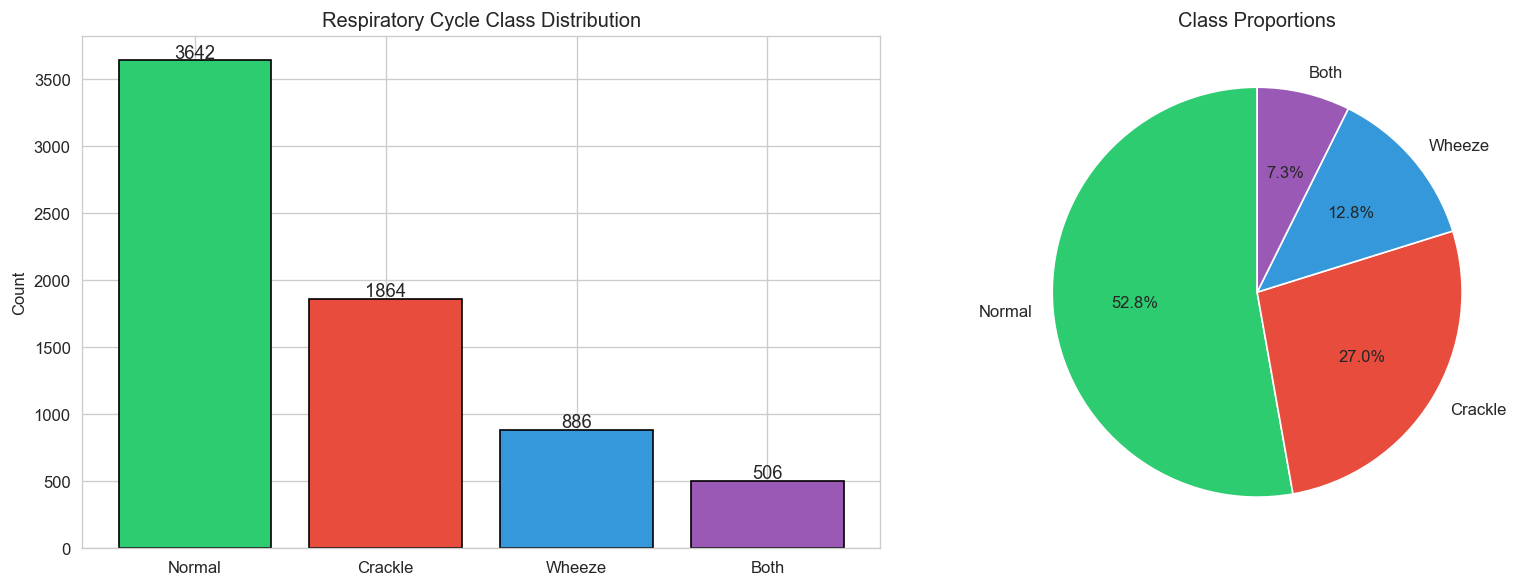

In [10]:
# Cycle class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
class_counts = cycle_df['label'].value_counts().sort_index()
bars = axes[0].bar(
    [CYCLE_CLASS_NAMES[i] for i in class_counts.index],
    class_counts.values,
    color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'],
    edgecolor='black'
)
axes[0].set_ylabel('Count')
axes[0].set_title('Respiratory Cycle Class Distribution')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', fontsize=11)

# Pie
axes[1].pie(
    class_counts.values,
    labels=[CYCLE_CLASS_NAMES[i] for i in class_counts.index],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'],
    startangle=90
)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cycle_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

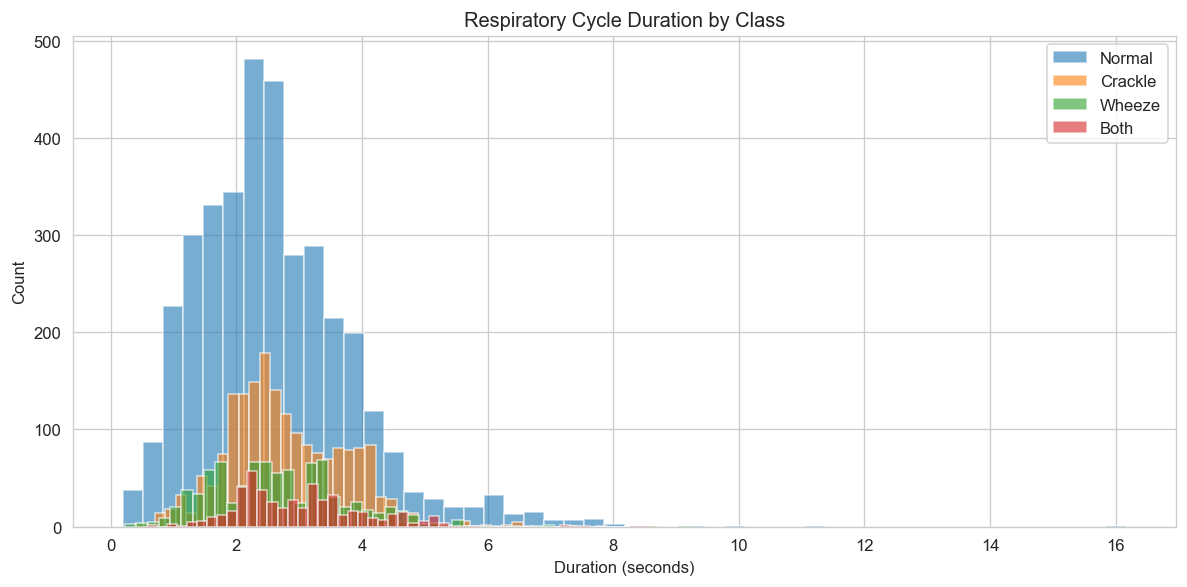

count    6898.000000
mean        2.700509
std         1.172534
min         0.200000
25%         1.932000
50%         2.537000
75%         3.369000
max        16.163000
Name: duration, dtype: float64


In [11]:
# Cycle duration distribution
fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(cycle_df['label'].unique()):
    subset = cycle_df[cycle_df['label'] == label]
    ax.hist(subset['duration'], bins=50, alpha=0.6, label=CYCLE_CLASS_NAMES[label])
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Respiratory Cycle Duration by Class')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cycle_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(cycle_df['duration'].describe())

## 1.3 Audio Visualisation

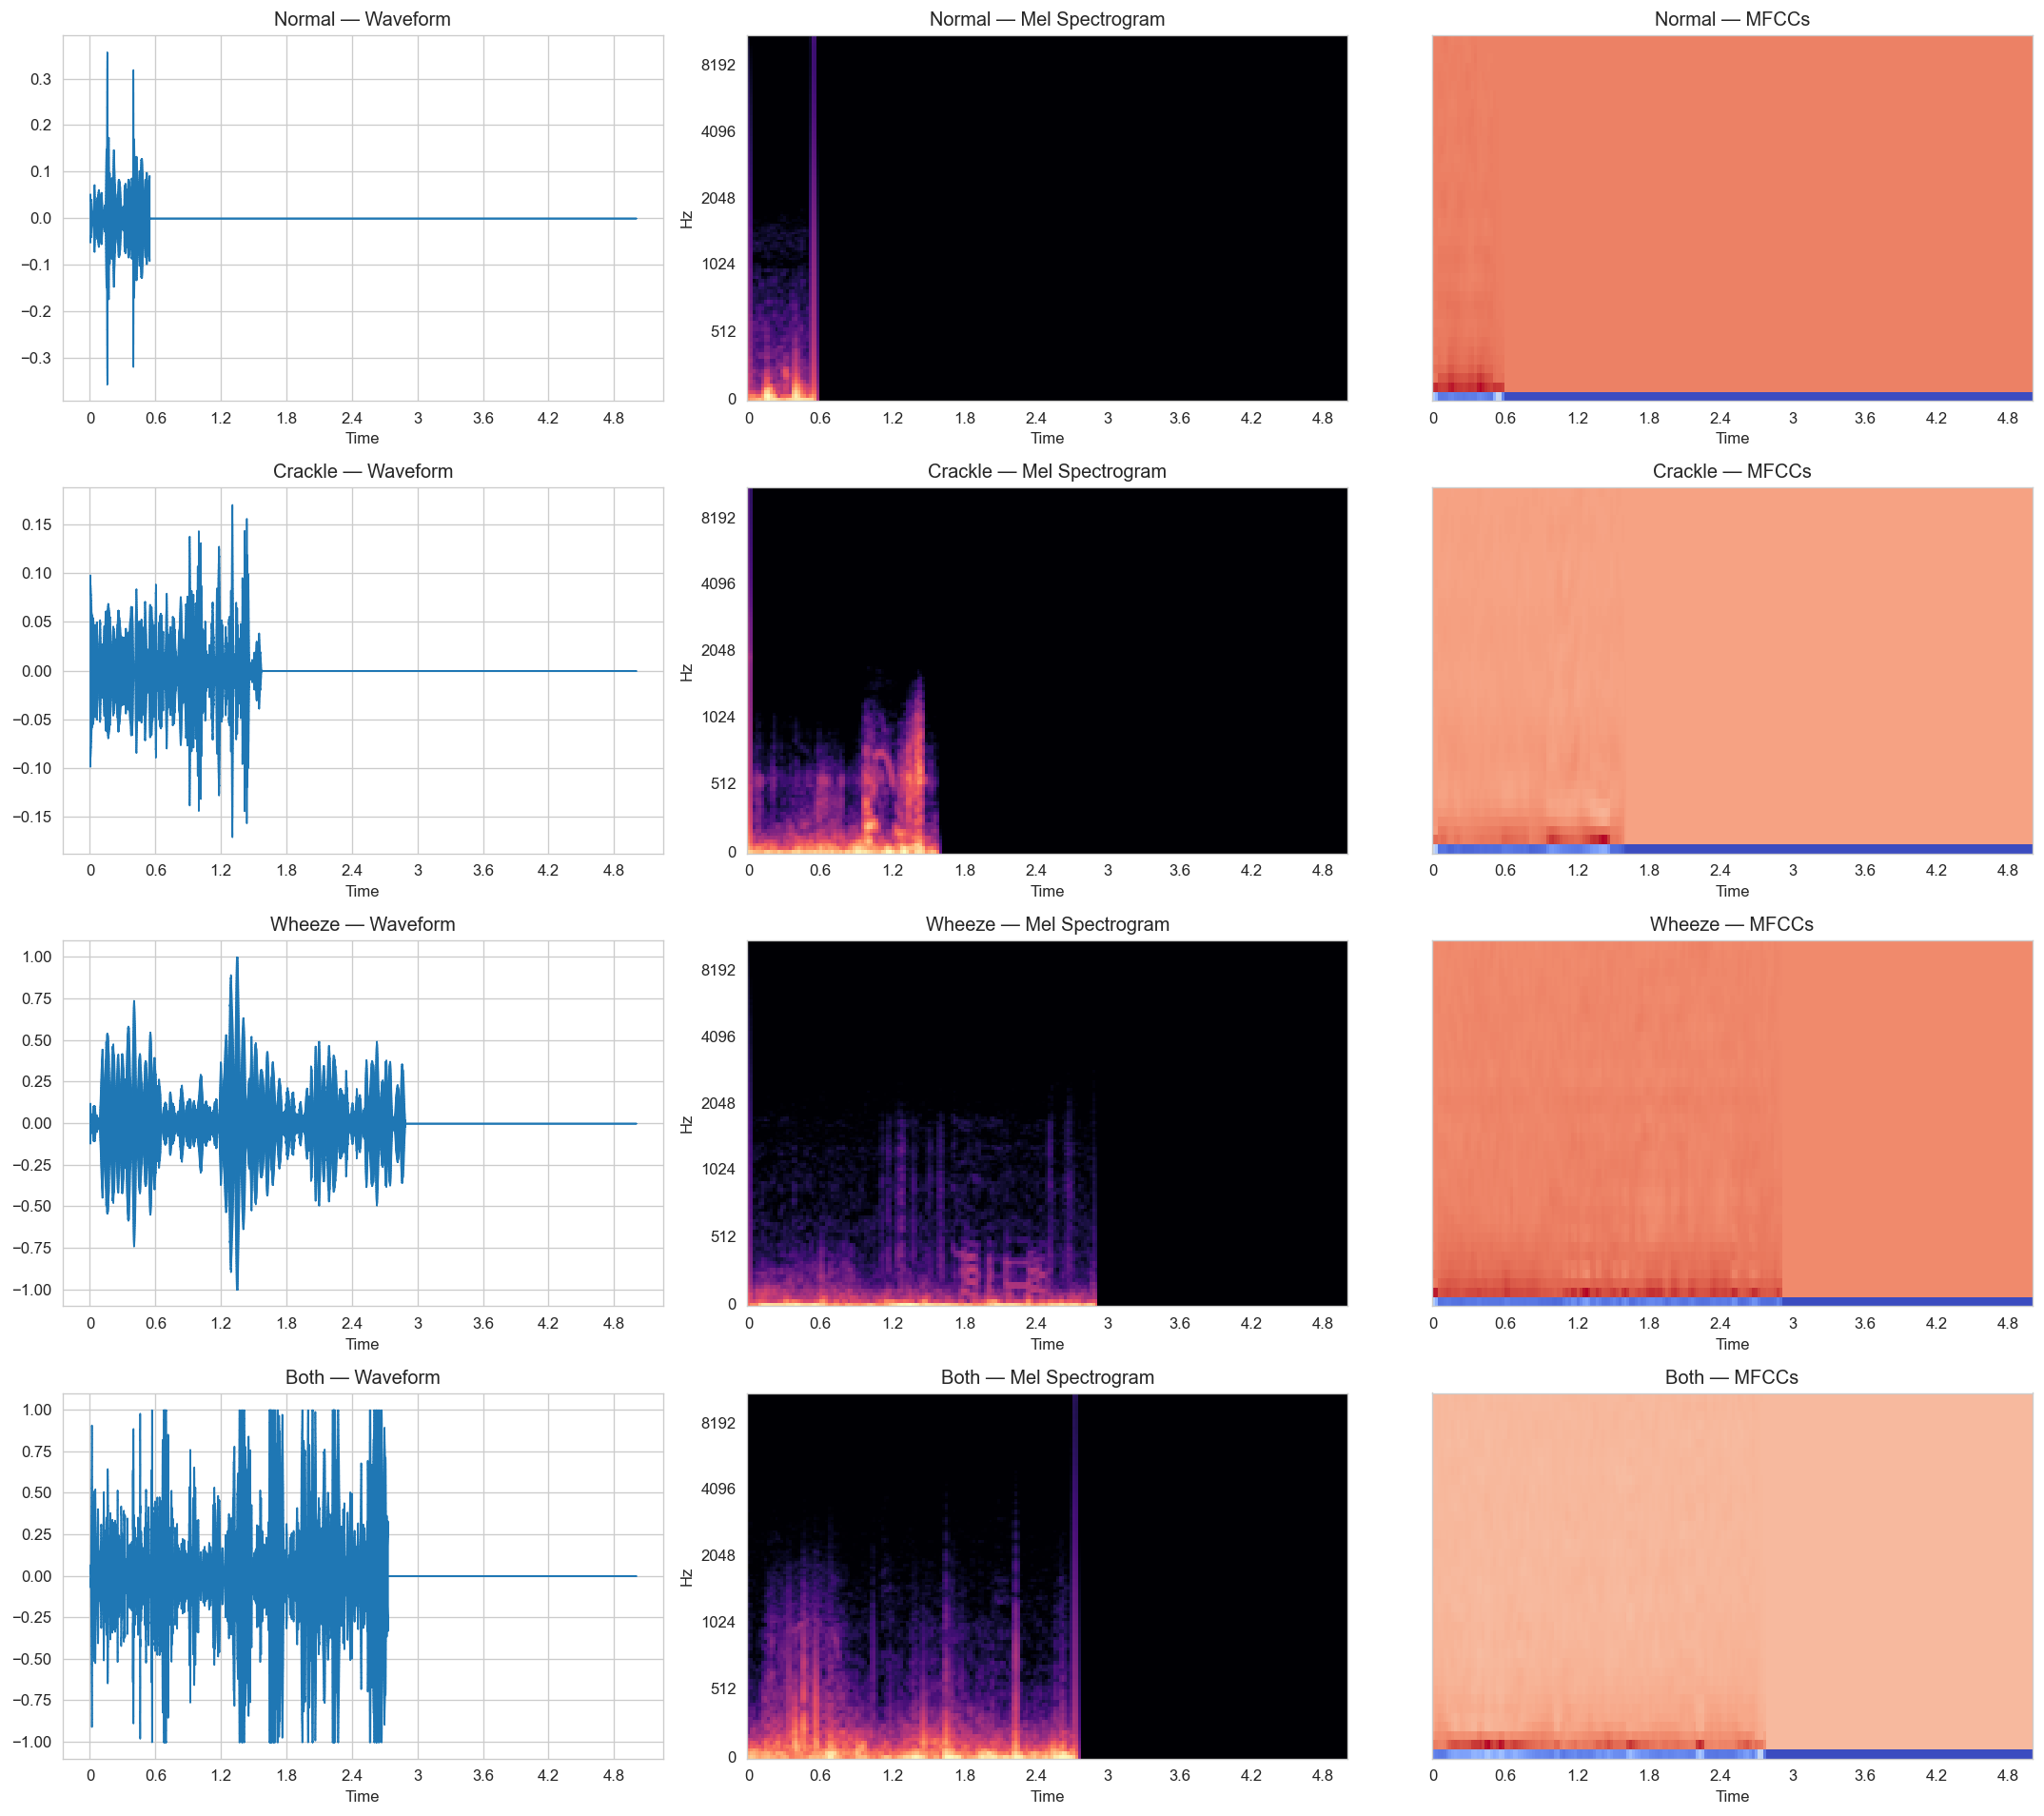

In [12]:
# Visualise one sample per class
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for i, label in enumerate(range(4)):
    sample = cycle_df[cycle_df['label'] == label].iloc[0]
    y = load_cycle_audio(sample['audio_path'], sample['start'], sample['end'])
    
    # Waveform
    librosa.display.waveshow(y, sr=SAMPLE_RATE, ax=axes[i, 0])
    axes[i, 0].set_title(f'{CYCLE_CLASS_NAMES[label]} — Waveform')
    
    # Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'{CYCLE_CLASS_NAMES[label]} — Mel Spectrogram')
    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    librosa.display.specshow(mfccs, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', ax=axes[i, 2])
    axes[i, 2].set_title(f'{CYCLE_CLASS_NAMES[label]} — MFCCs')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_audio_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Listen to sample audio for each class
for label in range(4):
    sample = cycle_df[cycle_df['label'] == label].iloc[0]
    y = load_cycle_audio(sample['audio_path'], sample['start'], sample['end'])
    print(f'\n{CYCLE_CLASS_NAMES[label]}:')
    ipd.display(ipd.Audio(y, rate=SAMPLE_RATE))


Normal:



Crackle:



Wheeze:



Both:


## 1.4 Chest Location & Equipment Analysis

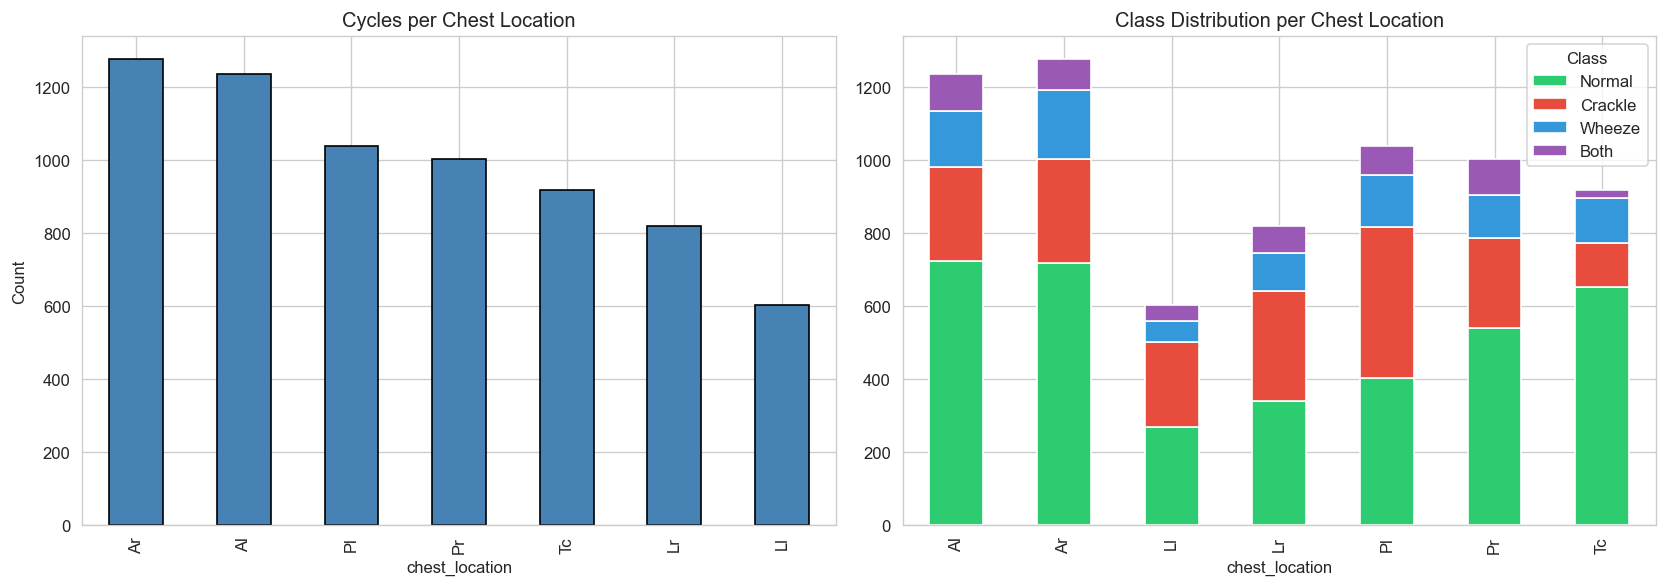

In [14]:
# Recordings per chest location
if 'chest_location' in cycle_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cycle_df['chest_location'].value_counts().plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
    )
    axes[0].set_title('Cycles per Chest Location')
    axes[0].set_ylabel('Count')
    
    # Class distribution per location
    ct = pd.crosstab(cycle_df['chest_location'], cycle_df['label'])
    ct.columns = [CYCLE_CLASS_NAMES[c] for c in ct.columns]
    ct.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
    axes[1].set_title('Class Distribution per Chest Location')
    axes[1].legend(title='Class')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'chest_location_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1.5 Summary Statistics

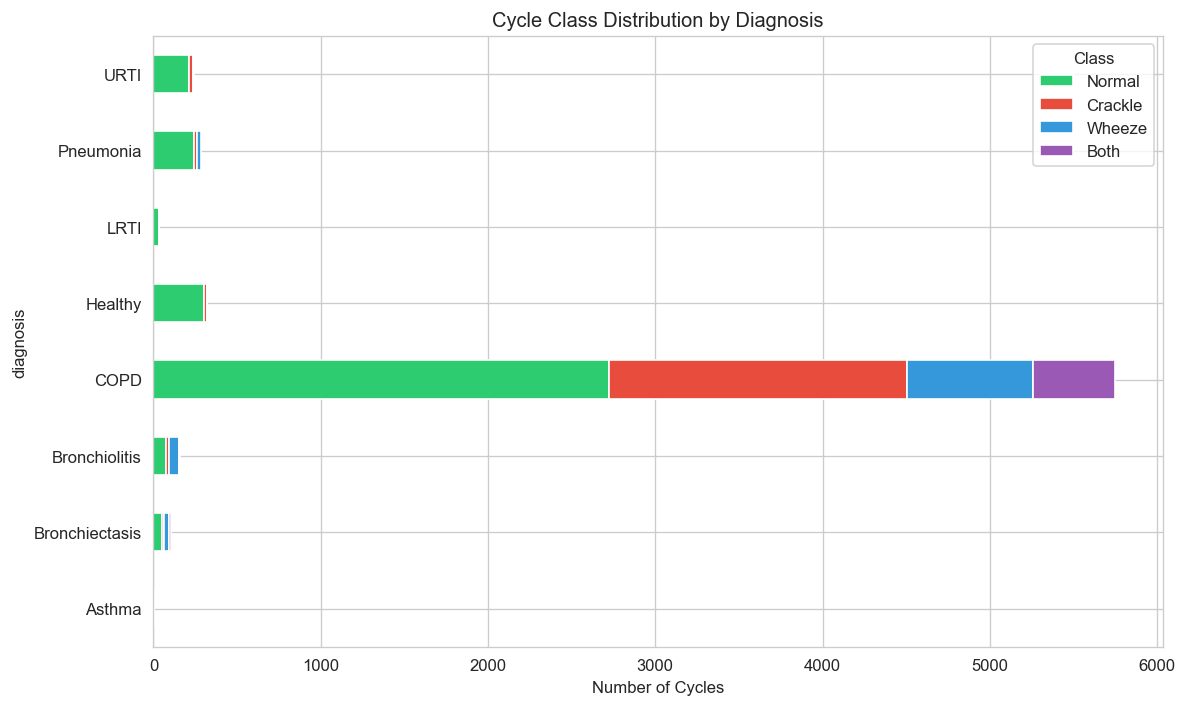

                Normal  Crackle  Wheeze  Both
diagnosis                                    
Asthma               2        0       4     0
Bronchiectasis      51       12      31    10
Bronchiolitis       76       15      64     5
COPD              2725     1779     752   490
Healthy            303       16       2     1
LRTI                31        0       1     0
Pneumonia          240       21      24     0
URTI               214       21       8     0


In [15]:
# Cross-tabulation: diagnosis × cycle class
if 'diagnosis' in cycle_df.columns:
    ct = pd.crosstab(cycle_df['diagnosis'], cycle_df['label'])
    ct.columns = CYCLE_CLASS_NAMES
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ct.plot(kind='barh', stacked=True, ax=ax,
            color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
    ax.set_title('Cycle Class Distribution by Diagnosis')
    ax.set_xlabel('Number of Cycles')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'diagnosis_vs_cycle_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(ct)

In [16]:
# Save the processed cycle dataset for downstream notebooks
cycle_df.to_csv(DATA_DIR / 'cycle_dataset.csv', index=False)
print(f'Saved cycle dataset: {len(cycle_df)} rows')

Saved cycle dataset: 6898 rows
